# Healthcare Operations & Billing Intelligence Dashboard
## Student Portfolio Project — Week 3 Application

**Role:** Junior Data Analyst / Business Intelligence Analyst  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook, GitHub  
**Dataset:** Healthcare dataset from Kaggle  
**Week 3 focus:** Data loading, inspection, cleaning, feature engineering, filtering, sorting, GroupBy, aggregation, visualisation, interpretation, and business recommendations.

---

## Important instruction for you

This notebook is written as a **student-facing project guide**. You are expected to do more than run code. For every major step, you must explain:

1. **What you did**  
2. **Why you did it**  
3. **What the result means for the business**  
4. **Why you chose a specific cleaning method or chart type**

A strong portfolio project does not only show code. It shows your thinking as a data analyst.

# 1. Business Scenario

You are working as a **Junior Data Analyst / Business Intelligence Analyst** for a healthcare organisation that manages patient admissions across several hospitals.

The organisation has patient records containing information such as age, gender, medical condition, hospital, insurance provider, admission type, billing amount, admission date, discharge date, medication, and test results.

The management team wants to understand:

- Which medical conditions create the highest patient demand.
- Which medical conditions generate the highest billing amounts.
- Which admission types are linked with higher costs.
- Which hospitals have the highest patient volume.
- How long patients stay in hospital.
- Whether certain groups of patients are associated with longer stays or higher bills.
- Whether test results vary across medical conditions.

Your job is to turn the raw healthcare data into a clear analytical report with charts, written interpretations, and business recommendations.

# 2. Main Business Problem

The healthcare organisation has a large patient admission dataset, but the leadership team does not yet have a clear view of the main operational and financial patterns in the data.

The business needs answers to this main question:

> **How can patient admission and billing data be used to identify cost drivers, operational pressure points, and opportunities to improve hospital planning and performance?**

Your project should help the organisation understand where demand, cost, and operational pressure are coming from.

# 3. Project Questions You Must Answer

You must answer the following questions in your analysis:

1. **Patient admission overview**  
   How are admissions distributed across medical conditions, hospitals, gender, and admission types?

2. **Medical condition analysis**  
   Which medical conditions are most common, and which generate the highest billing amounts?

3. **Hospital performance analysis**  
   Which hospitals handle the most admissions, and which hospitals generate the highest average billing amount?

4. **Admission type and cost analysis**  
   Do emergency, urgent, or elective admissions have different billing patterns?

5. **Length of stay analysis**  
   Which medical conditions or admission types are linked with longer hospital stays?

6. **Insurance provider analysis**  
   Which insurance providers are associated with the highest total and average billing?

7. **Age group analysis**  
   Which age groups have the highest admissions, billing, or length of stay?

8. **Test result analysis**  
   How are test results distributed across medical conditions?

At the end, you must write clear business recommendations based on your findings.

# 4. Expected Dataset Columns

Your healthcare dataset is expected to contain columns similar to these:

- `Name`
- `Age`
- `Gender`
- `Blood Type`
- `Medical Condition`
- `Date of Admission`
- `Doctor`
- `Hospital`
- `Insurance Provider`
- `Billing Amount`
- `Room Number`
- `Admission Type`
- `Discharge Date`
- `Medication`
- `Test Results`

## Important note

Your column names must match the dataset exactly. If your code gives a `KeyError`, run:

```python
print(df.columns.tolist())
```

This will show the exact spelling of each column.

# 5. Your Submission Requirements

Your final GitHub repository should include:

```text
healthcare-operations-analysis/
│
├── README.md
├── healthcare_analysis.ipynb
├── healthcare_dataset.csv
├── charts/
│   ├── admissions_by_condition.png
│   ├── billing_by_condition.png
│   ├── admission_type_cost.png
│   ├── length_of_stay_distribution.png
│   ├── monthly_admission_trend.png
│   └── test_results_heatmap.png
└── summary_report.md
```

Your notebook must include:

- A clear business problem.
- Dataset inspection.
- Data cleaning decisions.
- Reasons for using mean, median, mode, drop, or unknown values.
- Feature engineering.
- GroupBy summaries.
- At least 6 visualisations.
- Explanation of why each chart type was selected.
- Written interpretation under every chart.
- Final business recommendations.

# 6. Import Libraries

You need these libraries for the project:

- `pandas` for loading, cleaning, transforming, and analysing data.
- `matplotlib` for building charts.
- `seaborn` for professional statistical visualisations.
- `pathlib` for handling file paths.

Run the code below before any analysis.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set a professional visual theme for Seaborn charts
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


# 7. Load the Healthcare Dataset

You should download the healthcare dataset from Kaggle and save it in the same folder as this notebook.

Rename the file as:

```text
healthcare_dataset.csv
```

Then run the code below.

## Code you are expected to use

```python
df = pd.read_csv("healthcare_dataset.csv")
```

## Why this code is used

`pd.read_csv()` reads a CSV file and loads it into a Pandas DataFrame. A DataFrame is a table with rows and columns.

In [1]:
DATA_PATH = Path("healthcare_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "The file 'healthcare_dataset.csv' was not found. "
        "Download the Kaggle dataset, rename it as 'healthcare_dataset.csv', "
        "and place it in the same folder as this notebook."
    )

# Load the dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

NameError: name 'Path' is not defined

# 8. Inspect the Dataset

Before cleaning or analysing any dataset, you must inspect it.

## You must run these inspection commands on every dataset

```python
df.head()
df.shape
df.info()
df.describe()
df.isnull().sum()
df.duplicated().sum()
df.columns.tolist()
```

## Why inspection is important

Inspection helps you understand:

- How many rows and columns exist.
- What the column names are.
- Which columns are numeric.
- Which columns are text.
- Whether there are missing values.
- Whether there are duplicate rows.
- Whether the date columns need conversion.

You should never clean or visualise data before inspecting it.

In [ ]:
# Show the first 5 rows
df.head()

In [4]:
# Show number of rows and columns
df.shape

(10000, 15)

In [5]:
# Show column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                10000 non-null  object 
 1   Age                 10000 non-null  int64  
 2   Gender              10000 non-null  object 
 3   Blood Type          10000 non-null  object 
 4   Medical Condition   10000 non-null  object 
 5   Date of Admission   10000 non-null  object 
 6   Doctor              10000 non-null  object 
 7   Hospital            10000 non-null  object 
 8   Insurance Provider  10000 non-null  object 
 9   Billing Amount      10000 non-null  float64
 10  Room Number         10000 non-null  int64  
 11  Admission Type      10000 non-null  object 
 12  Discharge Date      10000 non-null  object 
 13  Medication          10000 non-null  object 
 14  Test Results        10000 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 1.1+

In [6]:
# Show summary statistics for numeric columns
df.describe()

,Age,Billing Amount,Room Number
count,10000.000000,10000.000000,10000.000000
mean,51.452200,25516.806778,300.082000
std,19.588974,14067.292709,115.806027
min,18.000000,1000.180837,101.000000
25%,35.000000,13506.523967,199.000000
50%,52.000000,25258.112566,299.000000
75%,68.000000,37733.913727,400.000000
max,85.000000,49995.902283,500.000000


In [7]:
# Check missing values per column
df.isnull().sum()

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [8]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [9]:
# Display exact column names
print(df.columns.tolist())

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


## Student task: write your dataset inspection notes

After running the inspection commands above, write your observations below.

You should answer:

1. How many rows and columns are in the dataset?
2. Which columns are numeric?
3. Which columns are categorical/text?
4. Are there missing values?
5. Are there duplicate rows?
6. Which columns need cleaning or type conversion?

### Your notes

Write your answer here:

- Dataset shape:
- Numeric columns:
- Text columns:
- Missing value observations:
- Duplicate observations:
- Columns requiring cleaning:

# 9. Data Cleaning Decision Guide: Mean, Median, Mode, Drop, or Unknown?

Data cleaning is one of the most important parts of this project. You must not fill missing values randomly. You must explain your decision.

When a column has missing values, your first question should be:

> What type of data is this column?

The answer determines the best cleaning method.

## 9.1 When to use the Mean

The **mean** is the average value.

Use the mean when:

- The column is numeric.
- The data is reasonably balanced or normally distributed.
- There are no extreme outliers that can distort the average.
- The missing percentage is small.

Example columns where mean may be considered:

- Age, if ages are evenly distributed.
- Billing Amount, if there are no extreme unusually high bills.
- Length of Stay, if there are no very extreme long stays.

## Example reason you can write

> The mean was considered because the column is numeric and represents a continuous measurement. However, the distribution was checked first to confirm whether extreme outliers were present.

## Warning

The mean is sensitive to outliers. If a few patients have extremely high billing amounts, the mean may become misleading.

## 9.2 When to use the Median

The **median** is the middle value when values are ordered.

Use the median when:

- The column is numeric.
- The data is skewed.
- There are outliers.
- You want a more robust central value.

Healthcare billing data is often skewed because some patients may have very high bills. In that situation, the median is often better than the mean.

## Example reason you can write

> The median was used because Billing Amount is a numeric column and healthcare billing often contains extreme values. The median is less affected by outliers than the mean, so it gives a more stable replacement value for missing billing records.

## 9.3 When to use the Mode

The **mode** is the most common value.

Use the mode when:

- The column is categorical/text.
- You need to fill missing values using the most frequent category.
- The most common category is meaningful and not misleading.

Example columns where mode may be considered:

- Gender
- Medical Condition
- Admission Type
- Insurance Provider
- Test Results
- Medication

## Example reason you can write

> The mode was used because Admission Type is a categorical column. Since the column contains labels rather than numbers, mean and median are not appropriate. The most frequent admission type was used to fill missing values.

## Warning

Sometimes using the mode can hide missing data patterns. If missing values are meaningful, using `Unknown` may be more honest.

## 9.4 When to use `Unknown`

Use `Unknown` when:

- The column is categorical/text.
- You do not want to assume the missing value is the most common category.
- Missingness itself may be important.

Example:

If `Insurance Provider` is missing, filling it with the most common provider may create false information. In that case, `Unknown` may be more honest.

## Example reason you can write

> Unknown was used because the missing insurance provider cannot be accurately inferred. Filling the missing value with the mode could create a false assumption, so Unknown preserves the fact that the information was not available.

## 9.5 When to drop rows or columns

Dropping data should be done carefully.

You may drop rows when:

- Only a very small percentage of rows are missing important values.
- The missing rows cannot be repaired.
- Removing them will not significantly reduce the dataset.

You may drop columns when:

- A column has too many missing values.
- The column is not important for your business questions.
- The column cannot be reliably cleaned.

## Example reason you can write

> Rows with missing Date of Admission were dropped because date is essential for monthly trend and length-of-stay analysis. Without admission date, those records cannot be used reliably for time-based analysis.

# 10. Check Missing Values and Decide Cleaning Strategy

Run the code below to produce a missing value report.

After running the code, you must write a short explanation of your cleaning decisions.

In [10]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Data_Type": df.dtypes
}).sort_values("Missing_Percentage", ascending=False)

missing_report

,Missing_Count,Missing_Percentage,Data_Type
Name,0,0.0,object
Age,0,0.0,int64
Gender,0,0.0,object
Blood Type,0,0.0,object
Medical Condition,0,0.0,object
Date of Admission,0,0.0,object
Doctor,0,0.0,object
Hospital,0,0.0,object
Insurance Provider,0,0.0,object
Billing Amount,0,0.0,float64


## Student task: write your missing value strategy

For every column with missing values, write:

1. Column name.
2. Data type.
3. Missing percentage.
4. Cleaning method selected: mean, median, mode, Unknown, drop row, or drop column.
5. Reason for your choice.

### Example format

| Column | Data Type | Missing % | Method Chosen | Reason |
|---|---|---:|---|---|
| Billing Amount | Numeric | 2.1% | Median | Billing values may contain outliers, so median is safer than mean. |
| Insurance Provider | Text | 4.5% | Unknown | Missing provider cannot be accurately inferred. |

Write your own decision table below.

# 11. Clean Column Names and Text Values

Text columns often contain extra spaces or inconsistent capitalisation.

For example:

```text
" emergency "
"Emergency"
"EMERGENCY"
```

Python sees these as different values unless you clean them.

## Code you are expected to use

```python
df["Admission Type"] = df["Admission Type"].str.strip().str.title()
```

## Why this code is used

- `.str.strip()` removes spaces before and after the text.
- `.str.title()` standardises capitalisation.

In [11]:
# Make a copy of the original dataset before cleaning
# This allows you to compare before and after if needed.
df_clean = df.copy()

# Remove exact duplicate rows
duplicates_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
duplicates_after = df_clean.duplicated().sum()

print(f"Duplicates before cleaning: {duplicates_before}")
print(f"Duplicates after cleaning: {duplicates_after}")

Duplicates before cleaning: 0
Duplicates after cleaning: 0


In [12]:
# Clean common text columns if they exist in the dataset
text_columns = [
    "Name", "Gender", "Blood Type", "Medical Condition", "Doctor", "Hospital",
    "Insurance Provider", "Admission Type", "Medication", "Test Results"
]

for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

print("Text columns cleaned where available.")

Text columns cleaned where available.


## Student task: explain your text cleaning decision

Write a short explanation below.

Your explanation should include:

- Why extra spaces can cause problems.
- Why consistent capitalisation is important.
- Which text columns you cleaned.

### Your explanation

Write your answer here.

# 12. Convert Date Columns

You need date columns for time-based analysis.

The two important date columns are usually:

- `Date of Admission`
- `Discharge Date`

These columns may load as text. You must convert them into real datetime columns.

## Code you are expected to use

```python
df_clean["Date of Admission"] = pd.to_datetime(df_clean["Date of Admission"])
df_clean["Discharge Date"] = pd.to_datetime(df_clean["Discharge Date"])
```

## Why this code is used

`pd.to_datetime()` allows Pandas to recognise a column as a real date. Once the column is a datetime column, you can extract year, month, quarter, weekday, and calculate length of stay.

In [13]:
# Convert date columns to datetime format
for col in ["Date of Admission", "Discharge Date"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

# Check date conversion
if "Date of Admission" in df_clean.columns:
    print("Date of Admission type:", df_clean["Date of Admission"].dtype)
if "Discharge Date" in df_clean.columns:
    print("Discharge Date type:", df_clean["Discharge Date"].dtype)

Date of Admission type: datetime64[ns]
Discharge Date type: datetime64[ns]


# 13. Convert Billing Amount to Numeric

The `Billing Amount` column should be numeric because you need to calculate totals, averages, medians, and visualise cost patterns.

Sometimes billing values may load as text. You should convert them to numeric.

## Code you are expected to use

```python
df_clean["Billing Amount"] = pd.to_numeric(df_clean["Billing Amount"], errors="coerce")
```

## Why this code is used

`pd.to_numeric()` converts a column into numbers. The argument `errors="coerce"` changes values that cannot be converted into `NaN`, so they can be cleaned properly.

In [14]:
if "Billing Amount" in df_clean.columns:
    df_clean["Billing Amount"] = pd.to_numeric(df_clean["Billing Amount"], errors="coerce")
    print("Billing Amount type:", df_clean["Billing Amount"].dtype)

Billing Amount type: float64


# 14. Investigate Numeric Distribution Before Filling Missing Values

Before choosing mean or median, you should inspect the distribution.

You can use:

- `mean()`
- `median()`
- `describe()`
- histogram
- box plot

If the mean and median are very different, or the boxplot shows outliers, the median may be safer.

In [15]:
if "Billing Amount" in df_clean.columns:
    print("Billing Amount summary:")
    print(df_clean["Billing Amount"].describe())
    print("Mean:", df_clean["Billing Amount"].mean())
    print("Median:", df_clean["Billing Amount"].median())

Billing Amount summary:
count    10000.000000
mean     25516.806778
std      14067.292709
min       1000.180837
25%      13506.523967
50%      25258.112566
75%      37733.913727
max      49995.902283
Name: Billing Amount, dtype: float64
Mean: 25516.8067777384
Median: 25258.112566373504


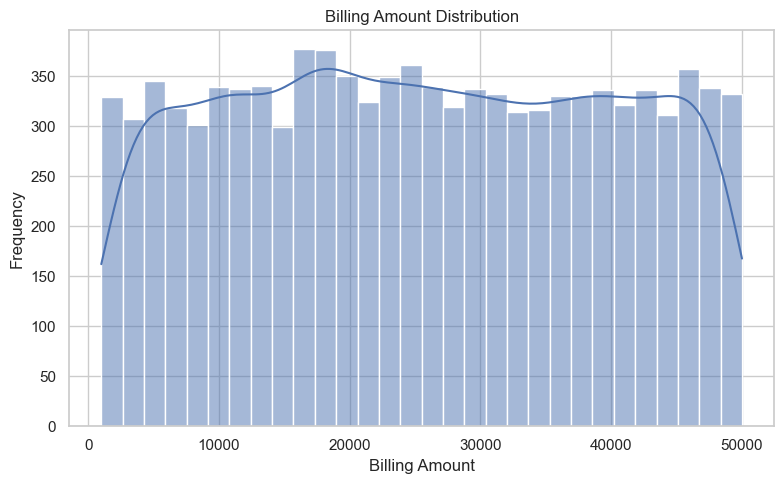

In [16]:
if "Billing Amount" in df_clean.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df_clean["Billing Amount"].dropna(), bins=30, kde=True)
    plt.title("Billing Amount Distribution")
    plt.xlabel("Billing Amount")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

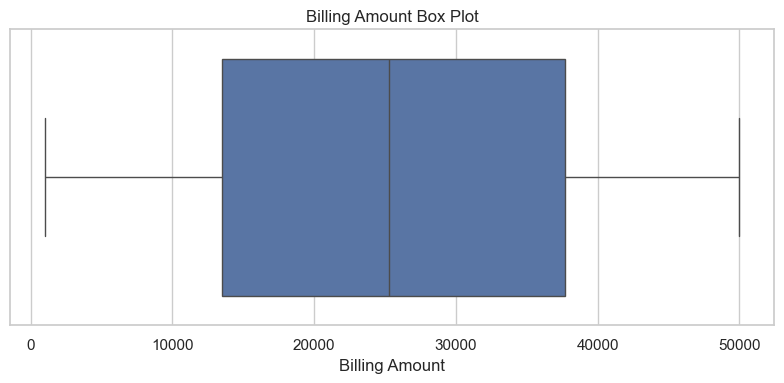

In [17]:
if "Billing Amount" in df_clean.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df_clean["Billing Amount"].dropna())
    plt.title("Billing Amount Box Plot")
    plt.xlabel("Billing Amount")
    plt.tight_layout()
    plt.show()

## Student task: choose mean, median, or mode for missing billing values

After viewing the summary, histogram, and box plot, write your decision.

Use this structure:

> I chose ________ to fill missing Billing Amount values because ________. The distribution appears ________, and the presence or absence of outliers means ________.

### Your explanation

Write your answer here.

# 15. Apply Missing Value Cleaning

The code below gives a safe example cleaning strategy. You may adjust it depending on your inspection findings.

## Important

Do not copy this blindly. You must explain why each method is appropriate for your dataset.

In [18]:
# Example cleaning strategy

# 1. Fill missing Billing Amount with median if the column exists
# Median is often safer for billing because billing can contain outliers.
if "Billing Amount" in df_clean.columns:
    billing_median = df_clean["Billing Amount"].median()
    df_clean["Billing Amount"].fillna(billing_median, inplace=True)

# 2. Fill missing categorical values with Unknown for selected columns
# Unknown is used where the true category cannot be confidently inferred.
unknown_fill_columns = ["Insurance Provider", "Medical Condition", "Admission Type", "Medication", "Test Results"]
for col in unknown_fill_columns:
    if col in df_clean.columns:
        df_clean[col].replace("Nan", pd.NA, inplace=True)  # handles earlier astype(str) conversion
        df_clean[col].fillna("Unknown", inplace=True)

# 3. Drop rows where critical date fields are missing, because length-of-stay analysis requires dates.
critical_date_cols = [col for col in ["Date of Admission", "Discharge Date"] if col in df_clean.columns]
if critical_date_cols:
    df_clean.dropna(subset=critical_date_cols, inplace=True)

# Check missing values after cleaning
df_clean.isnull().sum()

C:\Users\user\AppData\Local\Temp\ipykernel_6368\2228688928.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean["Billing Amount"].fillna(billing_median, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_6368\2228688928.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

## Student task: explain every cleaning step you applied

Use the structure below:

1. **Duplicates:**  
   I removed duplicate rows because...

2. **Text cleaning:**  
   I standardised text columns because...

3. **Date conversion:**  
   I converted date columns because...

4. **Billing Amount missing values:**  
   I used mean/median because...

5. **Categorical missing values:**  
   I used mode/Unknown because...

6. **Dropped rows or columns:**  
   I dropped these because...

# 16. Feature Engineering

Feature engineering means creating new useful columns from existing data.

For this healthcare project, you should create:

1. `Length_of_Stay`  
   Number of days between admission and discharge.

2. `Admission_Year`  
   Year of admission.

3. `Admission_Month`  
   Month number of admission.

4. `Admission_Month_Name`  
   Short month name such as Jan, Feb, Mar.

5. `Admission_Quarter`  
   Quarter of admission: 1, 2, 3, or 4.

6. `Age_Group`  
   Age category created using `pd.cut()`.

7. `Billing_Band`  
   Billing category such as Low, Medium, High, Very High.

## Why feature engineering is important

Raw data may not directly answer business questions. New columns help you analyse the data more meaningfully.

In [19]:
# Create Length_of_Stay
if "Date of Admission" in df_clean.columns and "Discharge Date" in df_clean.columns:
    df_clean["Length_of_Stay"] = (df_clean["Discharge Date"] - df_clean["Date of Admission"]).dt.days

# Extract admission date parts
if "Date of Admission" in df_clean.columns:
    df_clean["Admission_Year"] = df_clean["Date of Admission"].dt.year
    df_clean["Admission_Month"] = df_clean["Date of Admission"].dt.month
    df_clean["Admission_Month_Name"] = df_clean["Date of Admission"].dt.strftime("%b")
    df_clean["Admission_Quarter"] = df_clean["Date of Admission"].dt.quarter
    df_clean["Admission_Weekday"] = df_clean["Date of Admission"].dt.day_name()
    df_clean["Is_Weekend_Admission"] = df_clean["Date of Admission"].dt.dayofweek >= 5

# Create Age_Group
if "Age" in df_clean.columns:
    df_clean["Age_Group"] = pd.cut(
        df_clean["Age"],
        bins=[0, 18, 35, 50, 65, 120],
        labels=["0-18", "19-35", "36-50", "51-65", "66+"]
    )

# Create Billing_Band using quartiles if Billing Amount exists
if "Billing Amount" in df_clean.columns:
    df_clean["Billing_Band"] = pd.qcut(
        df_clean["Billing Amount"],
        q=4,
        labels=["Low", "Medium", "High", "Very High"],
        duplicates="drop"
    )

# Display engineered columns
engineered_cols = [
    "Length_of_Stay", "Admission_Year", "Admission_Month", "Admission_Month_Name",
    "Admission_Quarter", "Admission_Weekday", "Is_Weekend_Admission", "Age_Group", "Billing_Band"
]

existing_engineered_cols = [col for col in engineered_cols if col in df_clean.columns]
df_clean[existing_engineered_cols].head()

,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
0,14,2022,11,Nov,4,Thursday,False,66+,High
1,14,2023,6,Jun,2,Thursday,False,19-35,Very High
2,30,2019,1,Jan,1,Wednesday,False,51-65,High
3,1,2020,5,May,2,Saturday,True,36-50,Medium
4,24,2021,7,Jul,3,Friday,False,51-65,Medium


## Student task: explain your feature engineering

For each new column, write why it was created.

Example:

> `Length_of_Stay` was created because hospital management needs to understand how long patients stay after admission. This supports bed planning, staffing, and operational efficiency.

Write your explanations below.

# 17. Exploratory Data Analysis with GroupBy

GroupBy allows you to summarise data by category.

You should use:

```python
groupby()
agg()
sum()
mean()
count()
reset_index()
sort_values()
```

For each table you create, explain what business question it answers.

## 17.1 Admissions by Medical Condition

Business question:

> Which medical conditions appear most often in the dataset?

This helps identify the areas of highest patient demand.

In [20]:
condition_counts = (
    df_clean["Medical Condition"]
    .value_counts()
    .reset_index()
)
condition_counts.columns = ["Medical Condition", "Admission_Count"]
condition_counts

,Medical Condition,Admission_Count
0,Asthma,1708
1,Cancer,1703
2,Hypertension,1688
3,Arthritis,1650
4,Obesity,1628
5,Diabetes,1623


## 17.2 Billing by Medical Condition

Business question:

> Which medical conditions generate the highest total and average billing amounts?

This helps identify major cost and revenue drivers.

In [21]:
condition_billing = (
    df_clean.groupby("Medical Condition")
    .agg(
        Admission_Count=("Name", "count"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Billing=("Billing Amount", "mean"),
        Median_Billing=("Billing Amount", "median")
    )
    .reset_index()
    .sort_values("Total_Billing", ascending=False)
)

condition_billing

,Medical Condition,Admission_Count,Total_Billing,Average_Billing,Median_Billing
2,Cancer,1703,4.349308e+07,25539.096133,25610.641823
1,Asthma,1708,4.341201e+07,25416.869895,25073.451484
4,Hypertension,1688,4.253428e+07,25198.033973,24920.455173
3,Diabetes,1623,4.229557e+07,26060.116129,26162.203248
5,Obesity,1628,4.187353e+07,25720.842683,25365.022734
0,Arthritis,1650,4.155959e+07,25187.631255,24739.166756


## 17.3 Hospital Performance Summary

Business question:

> Which hospitals handle the most patients and which hospitals have the highest billing levels?

This helps management compare workload and financial patterns across hospitals.

In [22]:
hospital_summary = (
    df_clean.groupby("Hospital")
    .agg(
        Admission_Count=("Name", "count"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Billing=("Billing Amount", "mean")
    )
    .reset_index()
    .sort_values("Admission_Count", ascending=False)
)

hospital_summary.head(10)

,Hospital,Admission_Count,Total_Billing,Average_Billing
7115,Smith Plc,19,432283.548554,22751.765713
7110,Smith And Sons,17,477638.881124,28096.404772
7112,Smith Inc,14,351463.888372,25104.563455
7114,Smith Ltd,14,428163.073062,30583.076647
3770,Johnson Plc,13,269777.542385,20752.118645
8284,Williams Llc,12,327522.472644,27293.539387
8283,Williams Inc,12,245434.300373,20452.858364
7111,Smith Group,12,247635.075637,20636.256303
7562,Thomas Group,11,327045.374505,29731.397682
3769,Johnson Ltd,11,305971.192470,27815.562952


## 17.4 Admission Type and Cost Summary

Business question:

> Which admission type is associated with higher billing amounts?

This can help identify whether emergency, urgent, or elective admissions create greater financial and operational pressure.

In [23]:
admission_type_summary = (
    df_clean.groupby("Admission Type")
    .agg(
        Admission_Count=("Name", "count"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Billing=("Billing Amount", "mean"),
        Median_Billing=("Billing Amount", "median")
    )
    .reset_index()
    .sort_values("Average_Billing", ascending=False)
)

admission_type_summary

,Admission Type,Admission_Count,Total_Billing,Average_Billing,Median_Billing
2,Urgent,3391,8.803319e+07,25960.833557,25850.433905
0,Elective,3242,8.394132e+07,25891.832668,26120.772612
1,Emergency,3367,8.319356e+07,24708.511933,23900.173952


## 17.5 Length of Stay by Medical Condition

Business question:

> Which conditions are linked with longer hospital stays?

Longer stays affect bed availability, staffing, cost, and patient flow.

In [24]:
if "Length_of_Stay" in df_clean.columns:
    length_by_condition = (
        df_clean.groupby("Medical Condition")
        .agg(
            Average_Length_of_Stay=("Length_of_Stay", "mean"),
            Median_Length_of_Stay=("Length_of_Stay", "median"),
            Admission_Count=("Name", "count")
        )
        .reset_index()
        .sort_values("Average_Length_of_Stay", ascending=False)
    )
    display(length_by_condition)

,Medical Condition,Average_Length_of_Stay,Median_Length_of_Stay,Admission_Count
0,Arthritis,15.990303,16.0,1650
3,Diabetes,15.574245,16.0,1623
1,Asthma,15.481265,16.0,1708
2,Cancer,15.479742,15.0,1703
4,Hypertension,15.430095,15.0,1688
5,Obesity,15.421990,15.0,1628


## 17.6 Insurance Provider Billing Summary

Business question:

> Which insurance providers are linked with the highest billing totals and averages?

This can support finance, billing review, and payer relationship management.

In [25]:
insurance_summary = (
    df_clean.groupby("Insurance Provider")
    .agg(
        Patient_Count=("Name", "count"),
        Total_Billing=("Billing Amount", "sum"),
        Average_Billing=("Billing Amount", "mean")
    )
    .reset_index()
    .sort_values("Total_Billing", ascending=False)
)

insurance_summary

,Insurance Provider,Patient_Count,Total_Billing,Average_Billing
2,Cigna,2040,5.234017e+07,25656.946859
0,Aetna,2025,5.232179e+07,25837.923338
1,Blue Cross,2032,5.212586e+07,25652.489617
4,Unitedhealthcare,1978,5.025047e+07,25404.685388
3,Medicare,1925,4.812977e+07,25002.480429


## 17.7 Age Group Summary

Business question:

> Which age groups have the highest patient volume, billing, or hospital stay duration?

Age group analysis can support service planning and patient-care strategy.

In [26]:
if "Age_Group" in df_clean.columns:
    age_group_summary = (
        df_clean.groupby("Age_Group", observed=False)
        .agg(
            Patient_Count=("Name", "count"),
            Average_Billing=("Billing Amount", "mean"),
            Median_Billing=("Billing Amount", "median"),
            Average_Length_of_Stay=("Length_of_Stay", "mean") if "Length_of_Stay" in df_clean.columns else ("Billing Amount", "mean")
        )
        .reset_index()
    )
    display(age_group_summary)

,Age_Group,Patient_Count,Average_Billing,Median_Billing,Average_Length_of_Stay
0,0-18,164,26579.229435,28133.151204,15.774390
1,19-35,2490,25633.897045,25282.409375,15.483133
2,36-50,2142,25553.347493,25861.543764,15.474790
3,51-65,2270,25274.499932,24943.324975,15.511454
4,66+,2934,25518.842990,25033.958185,15.719155


# 18. Filtering Examples

Filtering allows you to focus on specific records.

You should use filtering when the business question starts with phrases such as:

- Show only emergency admissions.
- Show only patients with above-average bills.
- Show only long-stay patients.
- Show only abnormal test results.

In [27]:
# Emergency admissions
emergency_cases = df_clean[df_clean["Admission Type"] == "Emergency"]
emergency_cases.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin And Cooper",Unitedhealthcare,47304.064845,...,Normal,14,2023,6,Jun,2,Thursday,False,19-35,Very High
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton Llc,Medicare,36874.896997,...,Normal,30,2019,1,Jan,1,Wednesday,False,51-65,High
10,Amy Roberts,45,Male,B-,Cancer,2021-04-13,Anthony Roberts,Little-Spencer,Aetna,40325.071394,...,Abnormal,28,2021,4,Apr,2,Tuesday,False,36-50,Very High
11,Mrs. Caroline Farrell,23,Female,O-,Hypertension,2019-06-09,William Miller,Rose Inc,Medicare,6185.903530,...,Inconclusive,17,2019,6,Jun,2,Sunday,True,19-35,Low
14,Michael Bradshaw,65,Female,Ab+,Cancer,2021-06-05,Katherine Lowe,Castaneda-Hardy,Cigna,10342.836124,...,Inconclusive,20,2021,6,Jun,2,Saturday,True,51-65,Low


In [28]:
# Patients with billing above the dataset average
average_bill = df_clean["Billing Amount"].mean()
high_billing_cases = df_clean[df_clean["Billing Amount"] > average_bill]
high_billing_cases.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,...,Inconclusive,14,2022,11,Nov,4,Thursday,False,66+,High
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin And Cooper",Unitedhealthcare,47304.064845,...,Normal,14,2023,6,Jun,2,Thursday,False,19-35,Very High
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton Llc,Medicare,36874.896997,...,Normal,30,2019,1,Jan,1,Wednesday,False,51-65,High
6,Charles Horton,82,Male,Ab+,Hypertension,2021-03-22,Patricia Bishop,"Wheeler, Bryant And Johns",Cigna,39593.435761,...,Abnormal,24,2021,3,Mar,1,Monday,False,66+,Very High
10,Amy Roberts,45,Male,B-,Cancer,2021-04-13,Anthony Roberts,Little-Spencer,Aetna,40325.071394,...,Abnormal,28,2021,4,Apr,2,Tuesday,False,36-50,Very High


In [29]:
# Long-stay patients: adjust the threshold if needed
if "Length_of_Stay" in df_clean.columns:
    long_stay_cases = df_clean[df_clean["Length_of_Stay"] > 10]
    display(long_stay_cases.head())

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
0,Tiffany Ramirez,81,Female,O-,Diabetes,2022-11-17,Patrick Parker,Wallace-Hamilton,Medicare,37490.983364,...,Inconclusive,14,2022,11,Nov,4,Thursday,False,66+,High
1,Ruben Burns,35,Male,O+,Asthma,2023-06-01,Diane Jackson,"Burke, Griffin And Cooper",Unitedhealthcare,47304.064845,...,Normal,14,2023,6,Jun,2,Thursday,False,19-35,Very High
2,Chad Byrd,61,Male,B-,Obesity,2019-01-09,Paul Baker,Walton Llc,Medicare,36874.896997,...,Normal,30,2019,1,Jan,1,Wednesday,False,51-65,High
4,Mrs. Brandy Flowers,51,Male,O-,Arthritis,2021-07-09,Dustin Griffin,"Jones, Brown And Murray",Unitedhealthcare,18086.344184,...,Normal,24,2021,7,Jul,3,Friday,False,51-65,Medium
6,Charles Horton,82,Male,Ab+,Hypertension,2021-03-22,Patricia Bishop,"Wheeler, Bryant And Johns",Cigna,39593.435761,...,Abnormal,24,2021,3,Mar,1,Monday,False,66+,Very High


## Student task: explain one filter you used

Choose one filter and explain:

1. What rows you selected.
2. Why those rows matter.
3. What business question the filter helps answer.

# 19. Visualisation Guide: Which Graph Should You Use and Why?

You must choose the right graph for the business question.

A good chart is not just decoration. It should answer a question clearly.

## 19.1 Bar Chart

Use a **bar chart** when you want to compare categories.

Examples:

- Admissions by medical condition.
- Total billing by insurance provider.
- Average billing by admission type.
- Top 10 hospitals by admissions.

## Why a bar chart is suitable

A bar chart makes it easy to compare category sizes. The longest bar shows the largest value.

## When not to use it

Do not use a bar chart for continuous distributions or time trends where a line chart would be better.

## 19.2 Line Chart

Use a **line chart** when you want to show change over time.

Examples:

- Monthly admissions trend.
- Monthly billing trend.
- Quarterly revenue trend.

## Why a line chart is suitable

A line chart connects time points and helps the reader see whether values are increasing, decreasing, or fluctuating.

## When not to use it

Do not use a line chart for categories that have no natural order, such as hospitals or medical conditions.

## 19.3 Histogram

Use a **histogram** when you want to understand the distribution of one numeric variable.

Examples:

- Distribution of billing amount.
- Distribution of length of stay.
- Distribution of patient age.

## Why a histogram is suitable

A histogram shows where most values are concentrated. It helps you see skewness, spread, and unusual patterns.

## When not to use it

Do not use a histogram to compare named categories. Use a bar chart for that.

## 19.4 Box Plot

Use a **box plot** when you want to compare distribution, spread, and outliers across categories.

Examples:

- Billing amount by admission type.
- Billing amount by medical condition.
- Length of stay by medical condition.
- Billing amount by age group.

## Why a box plot is suitable

A box plot shows the median, spread, and outliers. This is useful in healthcare because billing and length of stay may contain extreme values.

## When not to use it

Do not use a box plot if your audience has no need to understand spread or outliers. A bar chart may be simpler for basic comparisons.

## 19.5 Heatmap

Use a **heatmap** when you want to show a matrix of values using colour.

Examples:

- Test results by medical condition.
- Monthly admissions by hospital.
- Monthly billing by admission type.

## Why a heatmap is suitable

A heatmap makes patterns visible across two categories. Darker or stronger colours usually show higher values.

## When not to use it

Do not use a heatmap when there are too many categories, because it can become difficult to read.

## 19.6 Scatter Plot

Use a **scatter plot** when you want to explore the relationship between two numeric variables.

Examples:

- Billing amount vs length of stay.
- Age vs billing amount.
- Age vs length of stay.

## Why a scatter plot is suitable

A scatter plot helps you see whether two numeric variables move together, whether there are clusters, or whether there are outliers.

## When not to use it

Do not use a scatter plot for category comparisons. Use bar charts or box plots instead.

# 20. Required Chart 1: Admissions by Medical Condition

## Business question

Which medical conditions are most common?

## Chart type

Bar chart.

## Why this chart type is appropriate

Medical condition is a category, and admission count is a number. A bar chart is the best choice because it compares counts across categories.

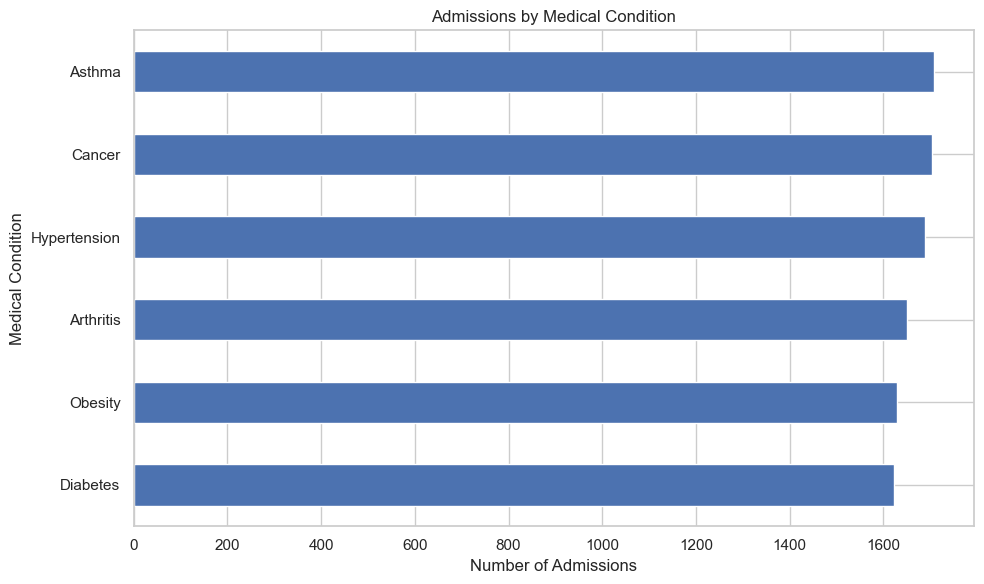

In [30]:
condition_counts = df_clean["Medical Condition"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
condition_counts.plot(kind="barh")
plt.title("Admissions by Medical Condition")
plt.xlabel("Number of Admissions")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig("admissions_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 1 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Which medical condition has the highest admissions?
- Which condition has the lowest admissions?
- What could this mean for hospital planning?

### Your interpretation

Write your answer here.

# 21. Required Chart 2: Total Billing by Medical Condition

## Business question

Which medical conditions generate the highest total billing?

## Chart type

Bar chart.

## Why this chart type is appropriate

You are comparing total billing across categories. A sorted bar chart makes it easy to identify the largest cost or revenue drivers.

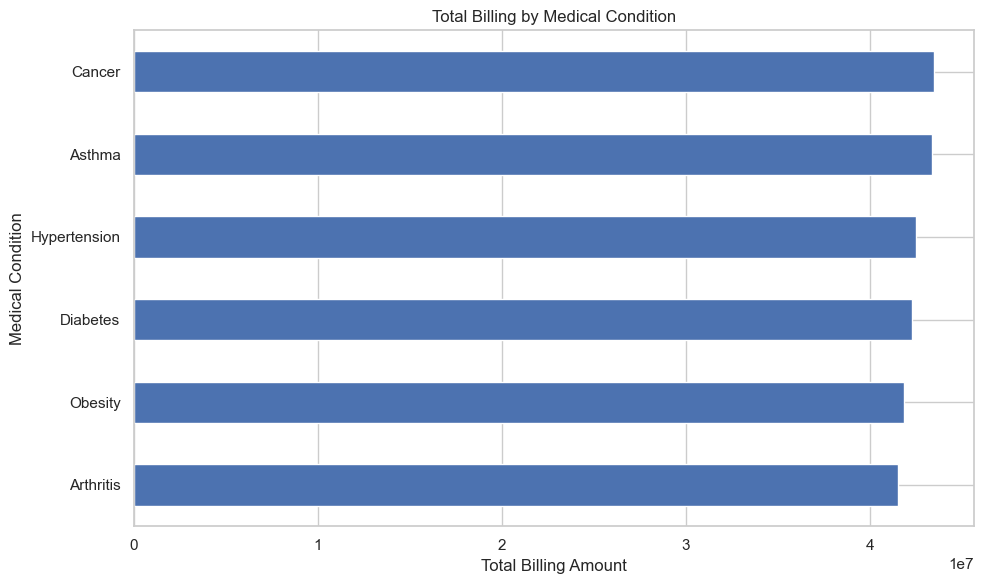

In [31]:
billing_by_condition = (
    df_clean.groupby("Medical Condition")["Billing Amount"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
billing_by_condition.plot(kind="barh")
plt.title("Total Billing by Medical Condition")
plt.xlabel("Total Billing Amount")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig("billing_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 2 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Which condition generates the highest total billing?
- Is the highest billing condition also the most common condition?
- What does this suggest about cost drivers?

### Your interpretation

Write your answer here.

# 22. Required Chart 3: Average Billing by Admission Type

## Business question

Do emergency, urgent, or elective admissions have different average billing amounts?

## Chart type

Bar chart for average comparison, and box plot if you want to show spread and outliers.

## Why this chart type is appropriate

A bar chart compares the average billing amount across admission types. A box plot gives deeper insight by showing the spread, median, and outliers.

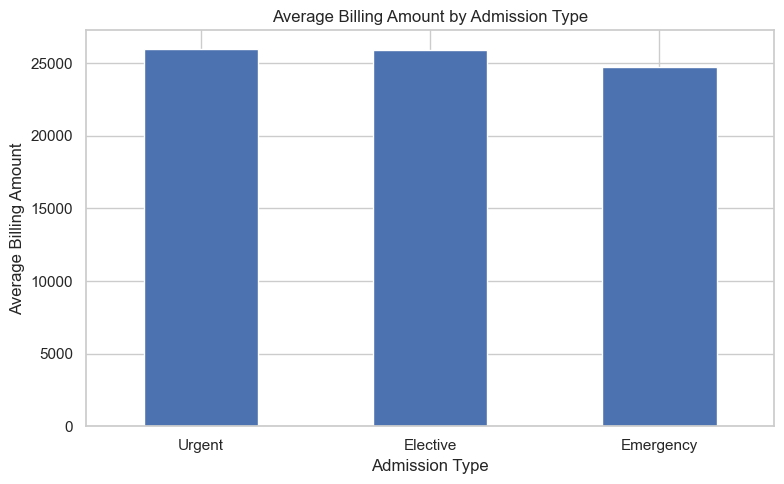

In [32]:
avg_billing_by_admission = (
    df_clean.groupby("Admission Type")["Billing Amount"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
avg_billing_by_admission.plot(kind="bar")
plt.title("Average Billing Amount by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("admission_type_cost.png", dpi=150, bbox_inches="tight")
plt.show()

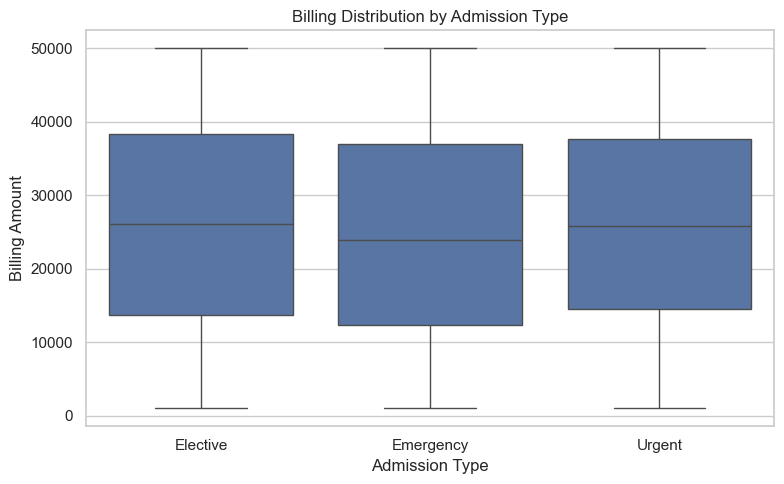

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Admission Type", y="Billing Amount")
plt.title("Billing Distribution by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Billing Amount")
plt.tight_layout()
plt.show()

## Chart 3 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Which admission type has the highest average billing?
- Does the box plot show outliers?
- What might this mean for hospital resource planning?

### Your interpretation

Write your answer here.

# 23. Required Chart 4: Length of Stay Distribution

## Business question

How long do patients usually stay in hospital?

## Chart type

Histogram.

## Why this chart type is appropriate

Length of stay is a numeric variable. A histogram shows how values are distributed and reveals whether most patients stay for a short or long period.

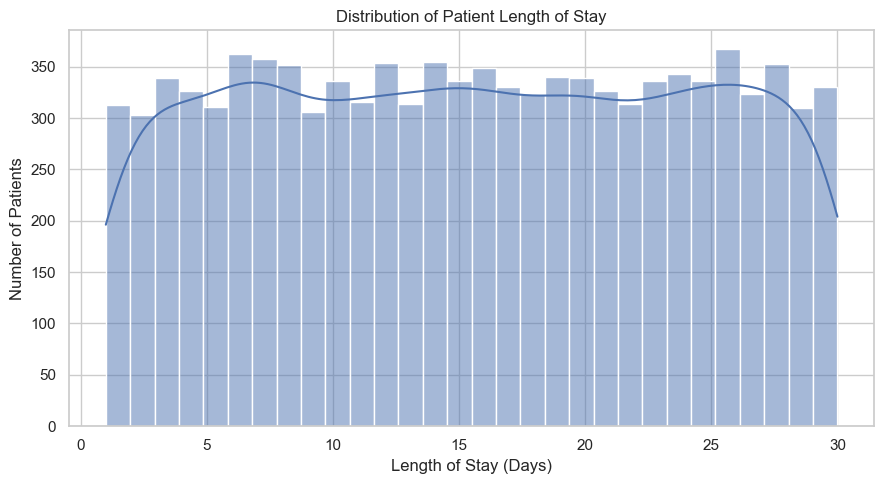

In [34]:
if "Length_of_Stay" in df_clean.columns:
    plt.figure(figsize=(9, 5))
    sns.histplot(df_clean["Length_of_Stay"], bins=30, kde=True)
    plt.title("Distribution of Patient Length of Stay")
    plt.xlabel("Length of Stay (Days)")
    plt.ylabel("Number of Patients")
    plt.tight_layout()
    plt.savefig("length_of_stay_distribution.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 4 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- What is the most common length of stay range?
- Are there very long stays?
- Why does length of stay matter to hospital operations?

### Your interpretation

Write your answer here.

# 24. Required Chart 5: Monthly Admission Trend

## Business question

Do patient admissions increase or decrease over time?

## Chart type

Line chart.

## Why this chart type is appropriate

A line chart is best for time trends. It helps you see whether admissions rise, fall, or fluctuate month by month.

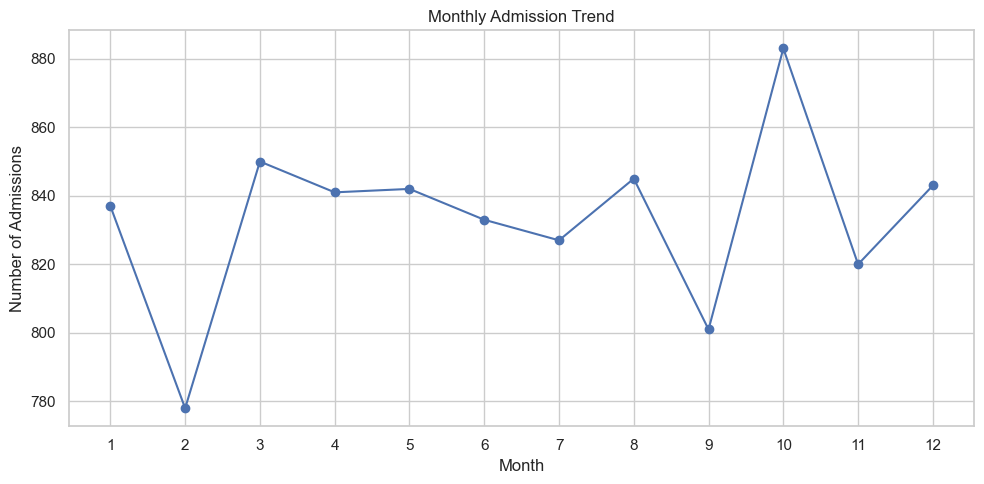

In [35]:
if "Admission_Month" in df_clean.columns:
    monthly_admissions = (
        df_clean.groupby("Admission_Month")
        .size()
        .reset_index(name="Admission_Count")
        .sort_values("Admission_Month")
    )

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_admissions["Admission_Month"], monthly_admissions["Admission_Count"], marker="o")
    plt.title("Monthly Admission Trend")
    plt.xlabel("Month")
    plt.ylabel("Number of Admissions")
    plt.xticks(range(1, 13))
    plt.tight_layout()
    plt.savefig("monthly_admission_trend.png", dpi=150, bbox_inches="tight")
    plt.show()

## Chart 5 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Which month had the highest admissions?
- Which month had the lowest admissions?
- Is there a visible seasonal pattern?

### Your interpretation

Write your answer here.

# 25. Required Chart 6: Test Results by Medical Condition

## Business question

How are test results distributed across medical conditions?

## Chart type

Heatmap.

## Why this chart type is appropriate

A heatmap is suitable because you are comparing two categorical variables: Medical Condition and Test Results. The colour intensity helps identify where certain test result types are concentrated.

In [36]:
test_condition_table = pd.crosstab(df_clean["Medical Condition"], df_clean["Test Results"])

test_condition_table

Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,555,553,542
Asthma,623,551,534
Cancer,577,556,570
Diabetes,537,542,544
Hypertension,602,554,532
Obesity,562,521,545


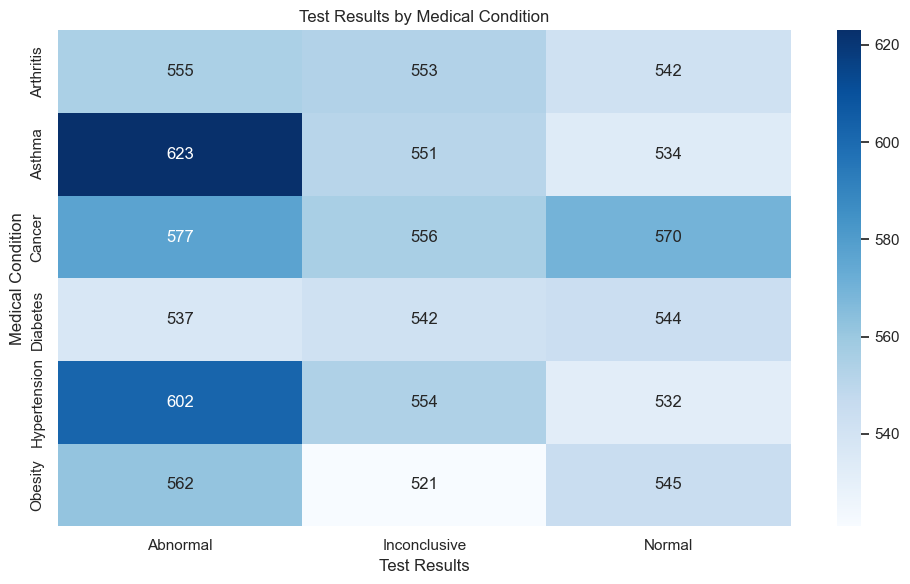

In [37]:
plt.figure(figsize=(10, 6))
sns.heatmap(test_condition_table, annot=True, fmt="d", cmap="Blues")
plt.title("Test Results by Medical Condition")
plt.xlabel("Test Results")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig("test_results_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Chart 6 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Which medical condition has the highest number of abnormal results?
- Are inconclusive results concentrated in any condition?
- What could this suggest for clinical review or operational planning?

### Your interpretation

Write your answer here.

# 26. Optional Chart 7: Billing Amount by Age Group

## Business question

Do billing patterns differ by age group?

## Chart type

Box plot.

## Why this chart type is appropriate

A box plot is useful because it compares billing distribution across age groups and shows outliers.

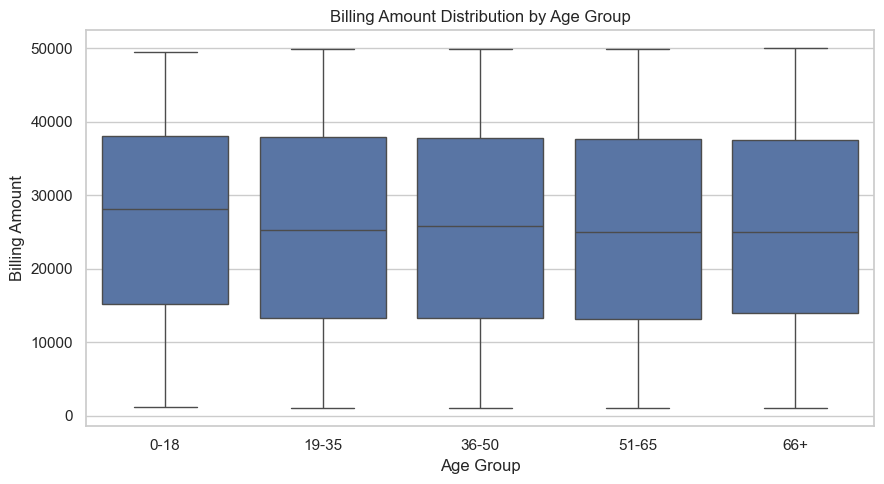

In [38]:
if "Age_Group" in df_clean.columns:
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=df_clean, x="Age_Group", y="Billing Amount")
    plt.title("Billing Amount Distribution by Age Group")
    plt.xlabel("Age Group")
    plt.ylabel("Billing Amount")
    plt.tight_layout()
    plt.show()

## Optional Chart 7 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Which age group has the highest median billing?
- Which age group shows the widest spread?
- Are there outliers?

### Your interpretation

Write your answer here.

# 27. Optional Chart 8: Billing Amount vs Length of Stay

## Business question

Is there a relationship between length of stay and billing amount?

## Chart type

Scatter plot.

## Why this chart type is appropriate

A scatter plot is appropriate because both variables are numeric. It helps you see whether longer hospital stays tend to be linked with higher billing amounts.

In [2]:
if "Length_of_Stay" in df_clean.columns:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df_clean, x="Length_of_Stay", y="Billing Amount", hue="Admission Type")
    plt.title("Billing Amount vs Length of Stay")
    plt.xlabel("Length of Stay (Days)")
    plt.ylabel("Billing Amount")
    plt.tight_layout()
    plt.show()

NameError: name 'df_clean' is not defined

## Optional Chart 8 Interpretation

Write 2–3 sentences.

Your interpretation should answer:

- Does billing appear to increase as length of stay increases?
- Are there clusters by admission type?
- Are there unusual outliers?

### Your interpretation

Write your answer here.

# 28. Executive Summary

At the top of your final notebook, you should include an executive summary.

The executive summary should be written for a non-technical manager.

It should answer:

- What dataset was analysed?
- What problem was investigated?
- What are the 3 most important findings?
- What should the organisation do next?

## Executive summary template

Use the structure below:

> This project analysed patient admission and billing data for a healthcare organisation. The aim was to identify admission patterns, cost drivers, length-of-stay trends, and operational pressure points. The three most important findings are: first, ________; second, ________; third, ________. Based on these findings, the organisation should ________.

### Your executive summary

Write your executive summary here.

# 29. Final Business Recommendations

You must write 3–5 recommendations based on your analysis.

A strong recommendation should be:

- Linked to evidence from your analysis.
- Practical for the healthcare organisation.
- Written in business language.

## Example recommendation structure

> Because [finding], the organisation should [action], so that [expected benefit].

## Example

> Because emergency admissions show higher average billing and wider cost variation, the organisation should review emergency department resource use and patient pathways, so that it can improve cost control and operational planning.

### Your recommendations

1. Recommendation 1:
2. Recommendation 2:
3. Recommendation 3:
4. Recommendation 4:
5. Recommendation 5:

# 30. Conclusion

Your conclusion should summarise what you learned and what the project demonstrates.

You should mention:

- Pandas data loading and inspection.
- Data cleaning decisions.
- Feature engineering.
- GroupBy analysis.
- Visualisation.
- Business interpretation.
- Portfolio value.

## Conclusion template

> This project demonstrated how Python and Pandas can be used to analyse healthcare operations and billing data. The analysis covered data loading, cleaning, feature engineering, GroupBy summaries, visualisation, and business interpretation. The findings provide useful insights into patient admissions, medical conditions, billing patterns, length of stay, and test results. This project strengthens my portfolio as a developing Data Analyst / Business Intelligence Analyst because it shows both technical ability and business understanding.

### Your conclusion

Write your conclusion here.

# 31. README Template for GitHub

Copy and adapt the README below for your GitHub repository.

```markdown
# Healthcare Operations and Billing Intelligence Dashboard

## Project Overview
This project analyses a healthcare admission dataset to understand patient admissions, billing patterns, hospital performance, length of stay, insurance provider trends, and test result outcomes.

## Business Problem
A healthcare provider needs better visibility into operational pressure points and billing drivers across hospitals, admission types, medical conditions, and patient groups.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook
- GitHub

## Key Skills Demonstrated
- Data loading
- Data inspection
- Data cleaning
- Feature engineering
- GroupBy aggregation
- Filtering and sorting
- Data visualisation
- Business interpretation

## Key Business Questions
1. Which medical conditions have the highest admission volume?
2. Which conditions generate the highest total billing?
3. Which admission types have the highest average billing?
4. Which patient groups stay longest in hospital?
5. How do test results vary by condition?

## Key Findings
- Finding 1: ...
- Finding 2: ...
- Finding 3: ...

## Recommendations
- Recommendation 1: ...
- Recommendation 2: ...
- Recommendation 3: ...

## Author
Your Name

## Programme
Inferaq Academy Data Analytics Programme
```

# 32. LinkedIn Showcase Post Template

Use this after you complete your notebook and push it to GitHub.

```text
I have completed a new healthcare data analytics project as part of my Data Analytics training with Inferaq Academy.

Project Title:
Healthcare Operations and Billing Intelligence Dashboard

In this project, I used Python, Pandas, Matplotlib, and Seaborn to analyse a healthcare admissions dataset and answer key business questions around:

- Patient admissions
- Medical conditions
- Hospital performance
- Billing patterns
- Insurance providers
- Length of stay
- Test results

This project helped me practise core data analyst skills, including data loading, data cleaning, feature engineering, GroupBy aggregation, filtering, sorting, visualisation, and business interpretation.

One important part of the project was explaining why each cleaning method and chart type was selected. This helped me think like a data analyst, not just write code.

The project has now been added to my GitHub portfolio as evidence of my growing skills as a Data Analyst / Business Intelligence Analyst.

#DataAnalytics #Python #Pandas #HealthcareAnalytics #BusinessIntelligence #GitHub #InferaqAcademy #LearningInPublic
```

# 33. Final Student Checklist

Before submitting, confirm that you have completed everything below.

## Data preparation

- [ ] Dataset loaded successfully.
- [ ] `df.head()` used.
- [ ] `df.shape` used.
- [ ] `df.info()` used.
- [ ] `df.describe()` used.
- [ ] Missing values checked.
- [ ] Duplicates checked.
- [ ] Date columns converted.
- [ ] Text columns cleaned.
- [ ] Cleaning choices explained.

## Feature engineering

- [ ] `Length_of_Stay` created.
- [ ] Admission month created.
- [ ] Admission quarter created.
- [ ] Age group created.
- [ ] Billing band created.
- [ ] Reasons for new columns explained.

## Analysis

- [ ] GroupBy used.
- [ ] Aggregation used.
- [ ] Sorting used.
- [ ] Filtering used.
- [ ] Business questions answered.

## Visualisation

- [ ] At least 6 charts created.
- [ ] Each chart has a clear title.
- [ ] Each chart has labelled axes.
- [ ] Each chart type choice is explained.
- [ ] Each chart has written interpretation.

## Portfolio submission

- [ ] Notebook saved.
- [ ] Charts saved as images.
- [ ] README completed.
- [ ] GitHub repository updated.
- [ ] LinkedIn post prepared.

# 34. Marking Rubric

| Criteria | Marks |
|---|---:|
| Clear business problem and project introduction | 10 |
| Correct data loading and inspection | 10 |
| Data cleaning and explanation of cleaning choices | 20 |
| Feature engineering and rationale | 10 |
| GroupBy analysis and business questions answered | 15 |
| Chart quality and correct chart selection | 15 |
| Written interpretations and recommendations | 10 |
| GitHub structure and README quality | 10 |
| **Total** | **100** |

## Important

You can lose marks if you show code without explaining why you used it. A professional analyst explains both the technical step and the business reason.